# Panoptica Tutorial: BraTS Metastasis Segmentation — Standard PQ & Part PQ

This tutorial demonstrates how to use **Panoptica** to evaluate brain metastasis segmentation using data from the BraTS-Mets 2025 challenge.

You will learn how to:
1. Perform per-region **Standard Panoptic Quality (PQ)** evaluation on the three BraTS sub-regions.
2. Use **Part Panoptic Quality** to evaluate hierarchical tumor structure (thing + parts).
3. Compare both approaches and interpret the results.

## 1. Setup & Installation

In [1]:
!pip install panoptica auxiliary nibabel matplotlib numpy rich > /dev/null


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import sys

try:
    import google.colab

    colabFlag = True
except ImportError:
    colabFlag = False

if colabFlag:
    from google.colab import drive

    drive.mount("/content/drive")
    !git clone https://github.com/BrainLesion/tutorials.git /content/drive/MyDrive/tutorials
    BASE_PATH = "/content/drive/MyDrive/tutorials/panoptica"
    sys.path.insert(0, BASE_PATH)
else:
    BASE_PATH = "."

## 2. Imports

In [3]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from rich import print as rprint

from panoptica import (
    InputType,
    Panoptica_Evaluator,
    ConnectedComponentsInstanceApproximator,
    NaiveThresholdMatching,
    Metric,
)
from panoptica.utils.segmentation_class import SegmentationClassGroups
from panoptica.utils.label_group import LabelGroup, LabelPartGroup

## 3. BraTS Metastasis Sub-regions

The BraTS-Mets 2025 segmentation masks contain three sub-region labels:

| Label | Region | Description |
|-------|--------|-------------|
| 1 | Necrotic Core (NCR) | Non-enhancing, necrotic tumor core |
| 2 | Peritumoral Edema (ED) | Surrounding edematous/invaded tissue |
| 3 | Enhancing Tumor (ET) | Actively enhancing tumor |

**Dataset:** BraTS-Path 2024 / BraTS-Mets 2025 challenge data.

In **Standard PQ**, each sub-region is evaluated independently as a separate class.

In **Part PQ**, the enhancing tumor and edema form the *thing* (the tumor instance), while the necrotic core is a *part* nested inside it — reflecting the biological hierarchy.

## 4. Load Data

In [4]:
data_dir = os.path.join(BASE_PATH, "brats_mets_data")

ref_nii = nib.load(os.path.join(data_dir, "reference.nii.gz"))
pred_nii = nib.load(os.path.join(data_dir, "prediction.nii.gz"))

ref_mask = ref_nii.get_fdata().astype(np.uint8)
pred_mask = pred_nii.get_fdata().astype(np.uint8)
voxelspacing = ref_nii.header.get_zooms()

print(f"Reference shape: {ref_mask.shape}, labels: {np.unique(ref_mask)}")
print(f"Prediction shape: {pred_mask.shape}, labels: {np.unique(pred_mask)}")
print(f"Voxel spacing: {voxelspacing}")

Reference shape: (240, 240, 155), labels: [0 1 2 3]
Prediction shape: (240, 240, 155), labels: [0 1 2 3]
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.0))


## 5. Standard PQ — Per Sub-region Evaluation

We evaluate each BraTS sub-region independently by defining a `SegmentationClassGroups` with one `LabelGroup` per label.
Each group is treated as a separate class: instances are extracted with Connected Components, then matched using NaiveThresholdMatching (IoU ≥ 0.5).

In [5]:
standard_groups = SegmentationClassGroups(
    {
        "Necrotic": LabelGroup(1),
        "Edema": LabelGroup(2),
        "Enhancing": LabelGroup(3),
    }
)

evaluator_standard = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=NaiveThresholdMatching(),
    segmentation_class_groups=standard_groups,
)

results_standard = evaluator_standard.evaluate(
    pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False
)

print(
    f"{'Region':<12} | {'PQ':<6} | {'SQ':<6} | {'RQ':<6} | {'TP':<4} | {'FP':<4} | {'FN':<4}"
)
print("-" * 55)
for name, res in results_standard.items():
    print(
        f"{name:<12} | {res.pq:.4f} | {res.sq:.4f} | {res.rq:.4f} | {res.tp:<4} | {res.fp:<4} | {res.fn:<4}"
    )

────────────────────────────────────────── Thank you for using panoptica ──────────────────────────────────────────

Please support our development by citing

https://github.com/BrainLesion/panoptica#citation -- Thank you!

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Region       | PQ     | SQ     | RQ     | TP   | FP   | FN  
-------------------------------------------------------
necrotic     | 0.0093 | 0.5142 | 0.0180 | 1    | 98   | 11  
edema        | 0.0533 | 0.7198 | 0.0741 | 1    | 24   | 1   
enhancing    | 0.2817 | 0.5634 | 0.5000 | 4    | 4    | 4   


## 6. Part PQ — Hierarchical Tumor Evaluation

Part PQ extends the standard panoptic quality to handle **hierarchical structures**: a *thing* object (the tumor instance) contains *part* objects (sub-regions).

Here we define:
- **Thing label**: Enhancing Tumor (3) — the primary active tumor instance
- **Part label**: Necrotic Core (1) — physically nested inside the enhancing rim
- **Standard group**: Peritumoral Edema (2) — evaluated independently as a regular class

Panoptica will:
1. Match enhancing tumor instances between prediction and reference (thing-level matching)
2. For each matched pair, score how well the necrotic core aligns (part-level scoring)
3. Evaluate edema separately as a standard LabelGroup

Isolated necrotic voxels with no enclosing enhancing tumor are automatically discarded.

In [6]:
part_groups = SegmentationClassGroups(
    {
        "tumor": LabelPartGroup(thing_labels=[3], part_labels=[1]),
        "edema": LabelGroup(2),
    }
)

evaluator_part = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=NaiveThresholdMatching(),
    segmentation_class_groups=part_groups,
)

results_part = evaluator_part.evaluate(
    pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False
)
res_part = results_part["tumor"]

print("--- Part PQ: Tumor-level matching ---")
print(f"  PQ:  {res_part.pq:.4f}")
print(f"  SQ:  {res_part.sq:.4f}")
print(f"  RQ:  {res_part.rq:.4f}")
print(f"  TP:  {res_part.tp}  |  FP: {res_part.fp}  |  FN: {res_part.fn}")

print("\n--- Part DSC per channel (part-level alignment) ---")
channel_dsc = res_part.get_channel_metrics("dsc")
channel_names = {0: "Necrotic (part)", 3: "Enhancing (thing)"}
if channel_dsc:
    for ch_label, dsc_val in channel_dsc.items():
        print(
            f"  {channel_names.get(ch_label, f'label {ch_label}')}: DSC = {dsc_val:.4f}"
        )

print("\n--- Edema (standard LabelGroup) ---")
res_edema = results_part["edema"]
print(f"  PQ:  {res_edema.pq:.4f}  SQ: {res_edema.sq:.4f}  RQ: {res_edema.rq:.4f}")
print(f"  TP:  {res_edema.tp}  |  FP: {res_edema.fp}  |  FN: {res_edema.fn}")

--- Part PQ: Tumor-level matching ---
  PQ:  0.2859
  SQ:  0.5719
  RQ:  0.5000
  TP:  4  |  FP: 4  |  FN: 4

--- Part DSC per channel (part-level alignment) ---
  Necrotic (part): DSC = 0.8544
  Enhancing (thing): DSC = 0.8060

--- Edema (standard LabelGroup) ---
  PQ:  0.0533  SQ: 0.7198  RQ: 0.0741
  TP:  1  |  FP: 24  |  FN: 1


## 7. Comparison: Standard PQ vs Part PQ

Standard PQ treats each sub-region independently — a necrotic lesion that is correctly located but inside a mis-matched edema region still counts as a TP.

Part PQ enforces the hierarchy: the necrotic core only scores well if its parent tumor instance was also correctly matched.

In [7]:
print(
    f"{'Method':<22} | {'PQ':<6} | {'SQ':<6} | {'RQ':<6} | {'TP':<4} | {'FP':<4} | {'FN':<4}"
)
print("-" * 67)

for name, res in results_standard.items():
    print(
        f"Standard [{name:<10}] | {res.pq:.4f} | {res.sq:.4f} | {res.rq:.4f} | {res.tp:<4} | {res.fp:<4} | {res.fn:<4}"
    )

print(
    f"Part PQ  [tumor     ] | {res_part.pq:.4f} | {res_part.sq:.4f} | {res_part.rq:.4f} | {res_part.tp:<4} | {res_part.fp:<4} | {res_part.fn:<4}"
)
print(
    f"Part PQ  [edema     ] | {res_edema.pq:.4f} | {res_edema.sq:.4f} | {res_edema.rq:.4f} | {res_edema.tp:<4} | {res_edema.fp:<4} | {res_edema.fn:<4}"
)

Method                 | PQ     | SQ     | RQ     | TP   | FP   | FN  
-------------------------------------------------------------------
Standard [necrotic  ] | 0.0093 | 0.5142 | 0.0180 | 1    | 98   | 11  
Standard [edema     ] | 0.0533 | 0.7198 | 0.0741 | 1    | 24   | 1   
Standard [enhancing ] | 0.2817 | 0.5634 | 0.5000 | 4    | 4    | 4   
Part PQ  [tumor     ] | 0.2859 | 0.5719 | 0.5000 | 4    | 4    | 4   
Part PQ  [edema     ] | 0.0533 | 0.7198 | 0.0741 | 1    | 24   | 1   


## 8. Threshold Analysis

The IoU matching threshold controls how much overlap is required to count a prediction as a True Positive.
Here we sweep from 0.05 to 0.95 using the Standard PQ (Enhancing Tumor class) and Part PQ to see how each degrades.

Sweeping thresholds...


  [thresh=0.05] Standard ET PQ=0.4814 | Part PQ=0.3703


  [thresh=0.10] Standard ET PQ=0.4814 | Part PQ=0.3703


  [thresh=0.15] Standard ET PQ=0.4814 | Part PQ=0.3703


  [thresh=0.20] Standard ET PQ=0.4814 | Part PQ=0.3703


...

  [thresh=0.75] Standard ET PQ=0.0000 | Part PQ=0.0000


  [thresh=0.80] Standard ET PQ=0.0000 | Part PQ=0.0000


  [thresh=0.85] Standard ET PQ=0.0000 | Part PQ=0.0000


  [thresh=0.90] Standard ET PQ=0.0000 | Part PQ=0.0000


  [thresh=0.95] Standard ET PQ=0.0000 | Part PQ=0.0000


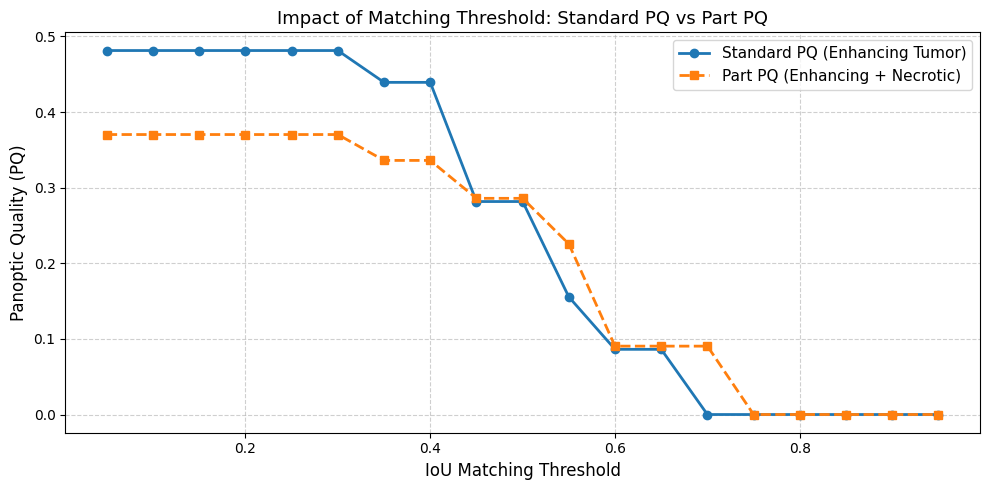

In [8]:
from panoptica.instance_matcher import NaiveThresholdMatching as NTM

thresholds = np.arange(0.05, 1.0, 0.05)
pq_enhancing = []
pq_part = []

print("Sweeping thresholds...")
for thresh in thresholds:
    matcher = NTM(matching_metric=Metric.IOU, matching_threshold=float(thresh))

    # Standard PQ — all sub-regions, extract Enhancing result
    ev_s = Panoptica_Evaluator(
        expected_input=InputType.SEMANTIC,
        instance_approximator=ConnectedComponentsInstanceApproximator(),
        instance_matcher=matcher,
        segmentation_class_groups=SegmentationClassGroups(
            {
                "Necrotic": LabelGroup(1),
                "Edema": LabelGroup(2),
                "Enhancing": LabelGroup(3),
            }
        ),
    )
    r_s = ev_s.evaluate(pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False)[
        "enhancing"
    ]
    pq_enhancing.append(r_s.pq)

    # Part PQ — Enhancing as thing, Necrotic as part
    ev_p = Panoptica_Evaluator(
        expected_input=InputType.SEMANTIC,
        instance_approximator=ConnectedComponentsInstanceApproximator(),
        instance_matcher=matcher,
        segmentation_class_groups=SegmentationClassGroups(
            {
                "tumor": LabelPartGroup(thing_labels=[3], part_labels=[1]),
                "edema": LabelGroup(2),
            }
        ),
    )
    r_p = ev_p.evaluate(pred_mask, ref_mask, voxelspacing=voxelspacing, verbose=False)[
        "tumor"
    ]
    pq_part.append(r_p.pq)

    print(f"  [thresh={thresh:.2f}] Standard ET PQ={r_s.pq:.4f} | Part PQ={r_p.pq:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    thresholds,
    pq_enhancing,
    marker="o",
    linewidth=2,
    label="Standard PQ (Enhancing Tumor)",
)
ax.plot(
    thresholds,
    pq_part,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Part PQ (Enhancing + Necrotic)",
)
ax.set_xlabel("IoU Matching Threshold", fontsize=12)
ax.set_ylabel("Panoptic Quality (PQ)", fontsize=12)
ax.set_title("Impact of Matching Threshold: Standard PQ vs Part PQ", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
plt.show()